# EDA Notebook — Flickr8k (Images + Captions)

This notebook performs exploratory data analysis (EDA) on the Flickr8k dataset (captions + images).

My goal in doing "EDA" is to discover the characteristics of the dataset so that by understanding them I can make a more accurate choice for my model architecture.

**Workflow summary**:
1. Install required packages.
2. Mount Drive or Upload by share link (Based on my network situation).
3. Unzip and normalize layout into /content/flickr8k/.
4. Caption EDA (textual): tokenization, vocab, lengths, CSV/JSON outputs.
5. Image EDA (visual & numeric): sizes, aspect ratios, color mode, sample grids, duplicate detection.
6. ResNet feature extraction + PCA scatter for visual clusters.

Outputs (CSVs, JSON, PNG plots, .npy features) are saved to `/content/eda_outputs/`.


1-Installation of the required libraries

In [1]:
# Install packages I'll need for EDA.
# If some packages are already present, pip will skip reinstalling them.
!pip install --quiet kaggle pillow imagehash torchvision==0.14.1 torch==1.13.1 tqdm scikit-learn pandas matplotlib nltk

# Download NLTK punkt tokenizer data (used if I choose a tokenizer).
import nltk
nltk.download('punkt')


ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.14.1 (from versions: 0.17.0, 0.17.1, 0.17.2, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0)
ERROR: No matching distribution found for torchvision==0.14.1


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

2-Imports, paths and creation of the output folder

In [2]:
!pip install --upgrade --no-cache-dir imagehash pillow

# Quick check, since I recieved errors.
import imagehash
from PIL import Image
print("imagehash imported, Pillow version:", Image.__version__)


imagehash imported, Pillow version: 12.0.0


In [3]:
# Set up my workspace paths and import everything I use repeatedly.
import os
from pathlib import Path
import json
import csv
import shutil
import re
from collections import Counter, defaultdict
from PIL import Image, ImageOps
import imagehash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
import torch
import torchvision.transforms as T
import torchvision.models as models

# Make a neat output folder (local VM only)
OUT_DIR = Path("/content/eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

# Where the unzipped dataset will be
# Note: First I tried to use kaggle API but because of the horrible network situation I forced to try mount drive and share link as a substituted methods, So don't be surprised by some "extra works".
DATA_DIR = Path("/content/flickr8k")
IMAGE_DIR = DATA_DIR / "Flickr8k_Dataset" / "Flickr8k_Dataset"
CAPTIONS_FILE = DATA_DIR / "Flickr8k_text" / "Flickr8k.token.txt"

print("Output folder:", OUT_DIR)
print("Expect captions at:", CAPTIONS_FILE)


Output folder: /content/eda_outputs
Expect captions at: /content/flickr8k/Flickr8k_text/Flickr8k.token.txt


3- Mount Google Drive OR download by share-link,gdown. (Based on Net situation)

In [7]:
# I mount Drive so I can access files uploaded there.
# from pathlib import Path
# import shutil, os, sys

# Mount Drive
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
    print("Drive mounted at /content/drive. Looking for zip files in MyDrive...")
except Exception as e:
    DRIVE_ROOT = None
    print("Drive mount not available or failed:", e)
# Maybe someone wants to run this notebook on his own system, it should seem professional there too.
    print("If prefer to provide a shareable link instead, uncomment and use the gdown section below.")

# search Drive for zip names.
found_zips = []
if DRIVE_ROOT and DRIVE_ROOT.exists():
    # search up to depth 3 to avoid long waits
    for p in DRIVE_ROOT.rglob("*.zip"):
        if any(k in p.name.lower() for k in ["image", "images", "archive", "captions", "caption"]):
            found_zips.append(p)

print("Zip files found in Drive (Images/captions/archive):")
for p in found_zips[:30]:
    print("  -", p)

# If I decided to use a share link:
!pip install --quiet gdown
import gdown
url = "https://drive.google.com/file/d/1zq1WQdMFQngm953xk-06YEeMSReDPKKT/view?usp=drive_link"
# gdown accepts the "uc?id=FILEID" or share link; it will try to extract the id automatically.
gdown.download(url, output="/content/my_shared_file.zip", quiet=False)

# After downloading via gdown, it proceed to the next cell to unzip and normalize.
# At this point, if two files uploaded to Drive (one zipped captions, one zipped Images),
# the next cell will try to locate them and unpack into /content/flickr8k/.

# If nothing was found by automatic search, there is no choice rather than I have to explicitly point to the files, so I have to set these variables:

# CAPTIONS_ZIP = "/content/drive/MyDrive/path/to/my_captions_zip.zip"
# IMAGES_ZIP   = "/content/drive/MyDrive/path/to/my_images_zip.zip"

# whenever I set them, the next cell will use these paths. Otherwise the next cell tries to auto-detect.


Mounting Google Drive...
Mounted at /content/drive
Drive mounted at /content/drive. Looking for zip files in MyDrive...
Zip files found in Drive (Images/captions/archive):
  - /content/drive/MyDrive/archive.zip


/usr/local/lib/python3.12/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=1zq1WQdMFQngm953xk-06YEeMSReDPKKT
  warnings.warn(
Downloading...
From: https://drive.google.com/file/d/1zq1WQdMFQngm953xk-06YEeMSReDPKKT/view?usp=drive_link
To: /content/my_shared_file.zip
108kB [00:00, 3.42MB/s]


'/content/my_shared_file.zip'

4-Unzip and normalize layout into /content/flickr8k/

In [9]:
# This cell and also, the cell before and after that is the symbol of my "Desperate Efforts" to just dump the data into my codes.
# If God wills and I get more time, I will sort these cells.
# If not, then This means that even tidying up the cell doesn't help.

# Unzip the captions zip and the images zip (copied from Drive or downloaded via gdown).
# Then normalize the layout so later cells can expect:
#   /content/flickr8k/Flickr8k_text/captions.txt   (or Flickr8k.token.txt)
#   /content/flickr8k/Flickr8k_Dataset/Flickr8k_Dataset/*.jpg  (symlinked)
#
# I tried several heuristics to don't copy image files (it creates a symlink),
# which is fast and avoids duplicating 1GB of images.

from pathlib import Path
import zipfile, shutil, os, glob

ROOT = Path("/content")
TARGET_ROOT = ROOT / "flickr8k"
TARGET_TEXT_DIR = TARGET_ROOT / "Flickr8k_text"
TARGET_IMAGE_DIR = TARGET_ROOT / "Flickr8k_Dataset" / "Flickr8k_Dataset"

# Create target dirs
TARGET_TEXT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_IMAGE_DIR.parent.mkdir(parents=True, exist_ok=True)

# Situation A: use explicit variables if I set them in the previous cell
try:
    CAPTIONS_ZIP  # may be i defined it in the previous cell
    IMAGES_ZIP
    explicit_set = True
except NameError:
    explicit_set = False

# Situation B: try to detect candidate zip files in Drive or /content
def find_candidate_zips():
    cand = []
    # check for explicit found_zips from previous cell's search (works just if I uncomment and ran the mount)
    try:
        from google.colab import drive  # if mount succeeded
        drive_root = Path("/content/drive/MyDrive")
        # look for common names
        for p in drive_root.rglob("*.zip"):
            name = p.name.lower()
            if "image" in name or "images" in name or "archive" in name or "captions" in name or "caption" in name:
                cand.append(p)
    except Exception:
        pass
    # also check top-level /content
    for p in Path("/content").glob("*.zip"):
        cand.append(p)
    return list(dict.fromkeys(cand))

if explicit_set:
    candidates = [Path(CAPTIONS_ZIP), Path(IMAGES_ZIP)]
else:
    candidates = find_candidate_zips()

print("Zip candidates to consider (first 30):")
for p in candidates[:30]:
    print(" -", p)

# Attempt to assign captions zip and images zip heuristically
captions_zip = None
images_zip = None
for p in candidates:
    n = p.name.lower()
    if "capt" in n or "caption" in n or "text" in n:
        captions_zip = p
    if "image" in n or "images" in n or "photos" in n:
        images_zip = p
    if "archive" in n or p.name.lower().startswith("archive"):
        # archive.zip often contains both; mark it as both if others not found
        if captions_zip is None:
            captions_zip = p
        if images_zip is None:
            images_zip = p

# If still not found, but a single archive exists, use it for both
if (captions_zip is None or images_zip is None) and candidates:
    if len(candidates) == 1:
        captions_zip = captions_zip or candidates[0]
        images_zip = images_zip or candidates[0]

print("Selected captions_zip:", captions_zip)
print("Selected images_zip:", images_zip)

# Unzip captions (I'll look inside to find a captions.txt or Flickr8k.token.txt)
def safe_unzip(src_zip, out_dir):
    if src_zip is None:
        return None
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    print("Unzipping", src_zip, "->", out_dir)
    try:
        with zipfile.ZipFile(str(src_zip), 'r') as z:
            z.extractall(str(out_dir))
        print(" Unzip OK.")
        return out_dir
    except zipfile.BadZipFile:
        print(" Bad zip file:", src_zip)
        return None

tmp_caps_unpacked = safe_unzip(captions_zip, ROOT / "caps_unpacked") if captions_zip else None
tmp_imgs_unpacked = safe_unzip(images_zip, ROOT / "imgs_unpacked") if images_zip else None

# If it unzipped an 'archive.zip', locate inner folders
def find_inner_captions(unpack_root):
    candidates = []
    if not unpack_root:
        return None
    for p in Path(unpack_root).rglob("*"):
        if p.is_file() and p.name.lower().startswith("capt") and p.suffix.lower() in [".txt", ".csv"]:
            candidates.append(p)
    return candidates[0] if candidates else None

def find_inner_images(unpack_root):
    # prefer a folder named "Images" containing many jpgs
    if not unpack_root:
        return None
    for p in Path(unpack_root).rglob("Images"):
        if p.is_dir() and len(list(p.glob("*.jpg"))) > 0:
            return p
    # fallback: any dir with many jpgs
    for p in Path(unpack_root).rglob("*"):
        if p.is_dir() and len(list(p.glob("*.jpg"))) > 200:
            return p
    return None

inner_captions = find_inner_captions(tmp_caps_unpacked) or find_inner_captions(tmp_imgs_unpacked)
inner_images = find_inner_images(tmp_imgs_unpacked) or find_inner_images(tmp_caps_unpacked)

print("Inner captions file found at:", inner_captions)
print("Inner images folder found at:", inner_images)

# If inner_captions found, copy it to TARGET_TEXT_DIR as 'captions.txt' and also create a 'Flickr8k.token.txt' symlink name
if inner_captions:
    dst = TARGET_TEXT_DIR / inner_captions.name
    if not dst.exists():
        shutil.copy2(str(inner_captions), str(dst))
    # Also create an alternate expected filename if needed by later cells
    alt = TARGET_TEXT_DIR / "Flickr8k.token.txt"
    if not alt.exists():
        shutil.copy2(str(inner_captions), str(alt))
    CAPTIONS_FILE = alt
    print("Captions copied to:", CAPTIONS_FILE)
else:
    # If no captions found, leave CAPTIONS_FILE None and the notebook will prompt later
    CAPTIONS_FILE = None
    print("No captions file detected in the unzipped content.May uploaded manually or re-check the zip.")

# For images: create a symlink target at TARGET_IMAGE_DIR pointing to the inner_images folder
if inner_images:
    try:
        if TARGET_IMAGE_DIR.exists():
            # remove existing symlink or dir if present
            if TARGET_IMAGE_DIR.is_symlink() or TARGET_IMAGE_DIR.is_dir():
                pass
        # remove if exists (be careful)
        if TARGET_IMAGE_DIR.exists() and not TARGET_IMAGE_DIR.is_symlink():
            pass  # leave it if it's a real folder already
        else:
            # create symlink
            os.symlink(str(inner_images.resolve()), str(TARGET_IMAGE_DIR))
            print("Created symlink for images:", TARGET_IMAGE_DIR, "->", inner_images)
        IMAGE_DIR = TARGET_IMAGE_DIR
    except Exception as e:
        # if symlink creation failed, fallback to using inner_images directly
        print("Could not create symlink (will use original image folder):", e)
        IMAGE_DIR = inner_images
else:
    IMAGE_DIR = None
    print("No images folder detected in the unzipped content.")

# Final printout
print("\nNormalization done.")
print(" TARGET_ROOT:", TARGET_ROOT)
print(" Captions file assumed at:", CAPTIONS_FILE)
print(" Image dir assumed at:", IMAGE_DIR)
print("\nIf CAPTIONS_FILE or IMAGE_DIR is None, please upload the missing zip to Drive or provide a share link and re-run the previous cell.")



Zip candidates to consider (first 30):
 - /content/drive/MyDrive/archive.zip
 - /content/my_shared_file.zip
Selected captions_zip: /content/drive/MyDrive/archive.zip
Selected images_zip: /content/drive/MyDrive/archive.zip
Unzipping /content/drive/MyDrive/archive.zip -> /content/caps_unpacked
 Unzip OK.
Unzipping /content/drive/MyDrive/archive.zip -> /content/imgs_unpacked
 Unzip OK.
Inner captions file found at: /content/caps_unpacked/captions.txt
Inner images folder found at: /content/imgs_unpacked/Images
Captions copied to: /content/flickr8k/Flickr8k_text/Flickr8k.token.txt
Created symlink for images: /content/flickr8k/Flickr8k_Dataset/Flickr8k_Dataset -> /content/imgs_unpacked/Images

Normalization done.
 TARGET_ROOT: /content/flickr8k
 Captions file assumed at: /content/flickr8k/Flickr8k_text/Flickr8k.token.txt
 Image dir assumed at: /content/flickr8k/Flickr8k_Dataset/Flickr8k_Dataset

If CAPTIONS_FILE or IMAGE_DIR is None, please upload the missing zip to Drive or provide a share 

5- Quick listing of key files, sanity check

In [10]:
# Quick check: list some of the files expected and show counts.
from pathlib import Path
OUT_DIR = Path("/content/eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Checking normalized locations...")

TARGET_ROOT = Path("/content/flickr8k")
TARGET_TEXT_DIR = TARGET_ROOT / "Flickr8k_text"
TARGET_IMAGE_DIR = TARGET_ROOT / "Flickr8k_Dataset" / "Flickr8k_Dataset"

print("Target root exists?:", TARGET_ROOT.exists())
print("Target text dir:", TARGET_TEXT_DIR, "exists:", TARGET_TEXT_DIR.exists())
print("Target image dir:", TARGET_IMAGE_DIR, "exists:", TARGET_IMAGE_DIR.exists())

# Print sample of captions file if present
if TARGET_TEXT_DIR.exists():
    captions_files = list(TARGET_TEXT_DIR.glob("*.txt"))
    print("Captions text files present:", [p.name for p in captions_files])
    if captions_files:
        print("\nFirst 5 lines of", captions_files[0])
        with open(captions_files[0], "r", encoding="utf-8", errors="replace") as fh:
            for i in range(5):
                line = fh.readline()
                if not line:
                    break
                print(f"  {i+1}: {line.strip()}")
else:
    print("No captions found in expected folder. Re-run the unzip/normalize cell or upload captions.")

# Count jpgs in the image dir (or the original images folder if not symlinked)
def count_jpgs(pth):
    try:
        return len(list(Path(pth).glob("*.jpg")))
    except Exception:
        return 0

jpg_count = count_jpgs(TARGET_IMAGE_DIR) if TARGET_IMAGE_DIR.exists() else 0
print("JPG count in target image dir:", jpg_count)

# If the symlink wasn't created but an images folder exists elsewhere, show some top-level folders in /content
if jpg_count == 0:
    print("\nNo images found at the expected path. Here are large folders under /content to inspect:")
    for p in sorted(Path("/content").iterdir()):
        if p.is_dir():
            jpgs = len(list(p.glob("*.jpg")))
            if jpgs > 0:
                print(" ", p, "-> jpgs:", jpgs)



Checking normalized locations...
Target root exists?: True
Target text dir: /content/flickr8k/Flickr8k_text exists: True
Target image dir: /content/flickr8k/Flickr8k_Dataset/Flickr8k_Dataset exists: True
Captions text files present: ['captions.txt', 'Flickr8k.token.txt']

First 5 lines of /content/flickr8k/Flickr8k_text/captions.txt
  1: image,caption
  2: 1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
  3: 1000268201_693b08cb0e.jpg,A girl going into a wooden building .
  4: 1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
  5: 1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
JPG count in target image dir: 8091


6- Parse captions file into a DataFrame, image to list of captions

In [11]:
# Read the caption file and create a structured DataFrame:
# The file format : "<image_name>#<caption_id>\t<caption text>"
# I'll map image -> 5 captions list and also create a row per (image, caption).

captions_path = str(CAPTIONS_FILE)
rows = []
with open(captions_path, "r", encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue
        # Expected: '12345.jpg#0\tA man is ...'
        if "\t" in line:
            left, cap = line.split("\t", 1)
        elif "  " in line:
            left, cap = line.split("  ", 1)
        else:
            # fallback: try first whitespace
            parts = line.split(maxsplit=1)
            if len(parts) == 2:
                left, cap = parts
            else:
                continue
        # left typically like '12345.jpg#0' -> split to get image name
        image_name = left.split("#")[0]
        rows.append((image_name, cap.strip()))

caps_df = pd.DataFrame(rows, columns=["image", "caption"])
# Save a row-per-caption CSV
caps_df.to_csv(OUT_DIR / "captions_raw_rows.csv", index=False, encoding="utf-8")
print("Rows:", len(caps_df), "Unique images:", caps_df['image'].nunique())
# Also create an aggregated mapping image -> list of captions
agg = caps_df.groupby("image")['caption'].apply(list).reset_index()
agg.to_json(OUT_DIR / "captions_by_image.json", orient="records", force_ascii=False)
agg.head()



Rows: 40453 Unique images: 21670


,image,caption
0,"1000268201_693b08cb0e.jpg,A",[child in a pink dress is climbing up a set of...
1,"1001773457_577c3a7d70.jpg,A","[black dog and a spotted dog are fighting, bla..."
2,"1001773457_577c3a7d70.jpg,Two",[dogs of different breeds looking at each othe...
3,"1002674143_1b742ab4b8.jpg,A",[little girl covered in paint sits in front of...
4,"1002674143_1b742ab4b8.jpg,There",[is a girl with pigtails sitting in front of a...


7- Caption tokenization, lengths, vocab, and JSON/CSV report

In [12]:
# I'll compute token stats, vocab, top tokens, caption length distribution, and save CSV/JSON.
# Use a simple tokenization: words defined by \w+ (letters, digits, underscore). Lowercase everything.

tok_re = re.compile(r"\w+")
def tokenize(s):
    return tok_re.findall(s.lower())

caps_df['tokens'] = caps_df['caption'].apply(tokenize)
caps_df['token_len'] = caps_df['tokens'].apply(len)

# Basic stats
total_captions = len(caps_df)
unique_images = caps_df['image'].nunique()
length_min = int(caps_df['token_len'].min())
length_max = int(caps_df['token_len'].max())
length_mean = float(caps_df['token_len'].mean())
length_median = float(caps_df['token_len'].median())

# Vocab counts
all_tokens = [t for toks in caps_df['tokens'] for t in toks]
token_counts = Counter(all_tokens)
vocab_size = len(token_counts)

top_tokens = token_counts.most_common(200)

# Save token frequencies to CSV
token_freq_df = pd.DataFrame(top_tokens, columns=["token", "count"])
token_freq_df.to_csv(OUT_DIR / "token_frequency.csv", index=False, encoding="utf-8")

# Caption length distribution to CSV
length_dist = caps_df['token_len'].value_counts().sort_index().reset_index()
length_dist.columns = ["token_length", "count"]
length_dist.to_csv(OUT_DIR / "caption_length_distribution.csv", index=False)

# Compose JSON report with main numbers
report = {
    "total_captions": total_captions,
    "unique_images": unique_images,
    "length_min": length_min,
    "length_max": length_max,
    "length_mean": length_mean,
    "length_median": length_median,
    "vocab_size": vocab_size,
    "top_tokens_sample": top_tokens[:50]  # save a sample in the report
}
with open(OUT_DIR / "captions_text_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

# Print a concise summary
print("Captured textual caption stats:")
print(" - total captions:", total_captions)
print(" - unique images:", unique_images)
print(" - caption length (min,max,mean,median):", length_min, length_max, round(length_mean,2), length_median)
print(" - vocab size:", vocab_size)
print(" - top 10 tokens:", top_tokens[:10])
print("Reports saved to:", OUT_DIR)


Captured textual caption stats:
 - total captions: 40453
 - unique images: 21670
 - caption length (min,max,mean,median): 1 36 9.82 9.0
 - vocab size: 8407
 - top 10 tokens: [('a', 38288), ('in', 18975), ('the', 15298), ('on', 10732), ('is', 9345), ('and', 8862), ('dog', 7979), ('with', 7760), ('man', 6819), ('of', 6722)]
Reports saved to: /content/eda_outputs


8- Plot: caption length histogram and save PNG

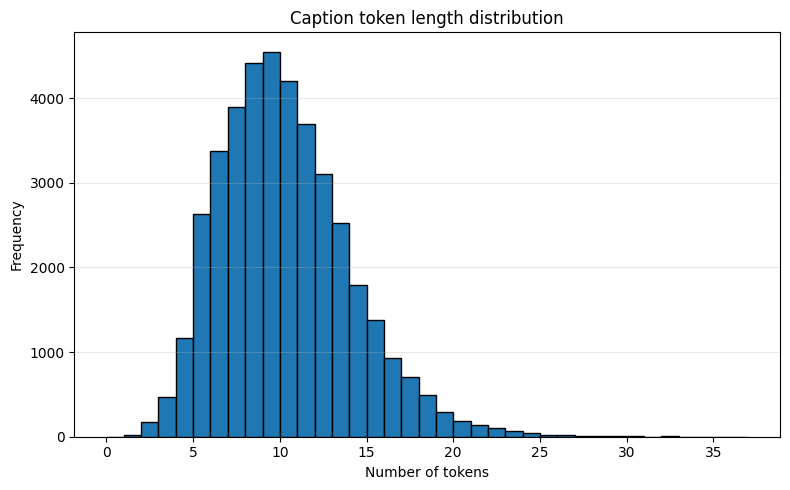

In [13]:
# Plot the caption length histogram and save the image.
plt.figure(figsize=(8,5))
plt.hist(caps_df['token_len'], bins=range(0, max(31, int(caps_df['token_len'].max())+2)), edgecolor='black')
plt.title("Caption token length distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "caption_length_histogram.png", dpi=150)
plt.show()


9- Plot: top-30 token frequencies (bar chart)

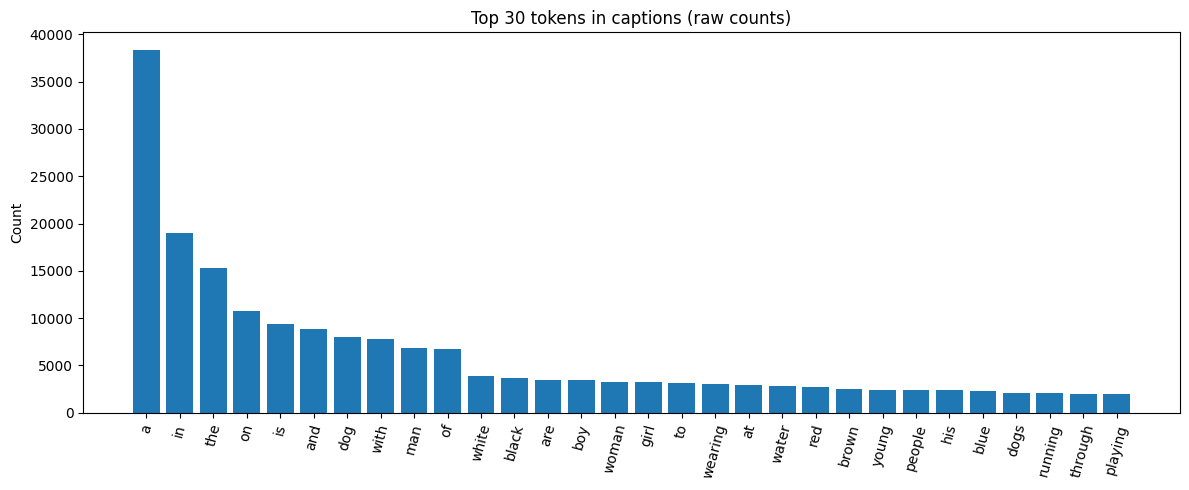

In [14]:
# Bar chart for top-30 tokens to include in report and give insights
top_n = 30
top30 = token_freq_df.head(top_n)
plt.figure(figsize=(12,5))
plt.bar(range(len(top30)), top30['count'])
plt.xticks(range(len(top30)), top30['token'], rotation=75)
plt.title(f"Top {top_n} tokens in captions (raw counts)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_DIR / "top_tokens_bar.png", dpi=150)
plt.show()


10- Caption-quality checks & special tokens

In [15]:
# Look for possible problems and special patterns: digits, non-ascii, quotes, commas, too short, too long.
caps_df['has_digit'] = caps_df['caption'].str.contains(r'\d')
caps_df['has_quote'] = caps_df['caption'].str.contains('"')
caps_df['has_comma'] = caps_df['caption'].str.contains(',')
caps_df['non_ascii'] = caps_df['caption'].apply(lambda s: any(ord(ch) > 127 for ch in s))

special_summary = {
    "captions_with_digits": int(caps_df['has_digit'].sum()),
    "captions_with_quotes": int(caps_df['has_quote'].sum()),
    "captions_with_commas": int(caps_df['has_comma'].sum()),
    "captions_non_ascii": int(caps_df['non_ascii'].sum()),
    "very_short_captions_le_2": int((caps_df['token_len'] <= 2).sum()),
    "long_captions_gt_20": int((caps_df['token_len'] > 20).sum())
}
print("Special token summary:", special_summary)
with open(OUT_DIR / "captions_special_summary.json", "w", encoding="utf-8") as f:
    json.dump(special_summary, f, indent=2)


Special token summary: {'captions_with_digits': 169, 'captions_with_quotes': 2540, 'captions_with_commas': 2447, 'captions_non_ascii': 0, 'very_short_captions_le_2': 202, 'long_captions_gt_20': 438}


11- Image-level EDA: sizes, aspect ratios, color mode (scans images)

In [16]:
# Build a DataFrame with basic stats for every image file.
# This scans all jpg files in IMAGE_DIR and records width, height, aspect ratio, mode, and file size.

image_paths = sorted(list(IMAGE_DIR.glob("*.jpg")))
img_stats = []
for p in tqdm(image_paths, desc="Scanning images"):
    try:
        with Image.open(p) as im:
            w, h = im.size
            mode = im.mode  # 'RGB', 'L', etc.
        fsize = p.stat().st_size
        img_stats.append({"image": p.name, "width": w, "height": h, "aspect_ratio": round(w/h, 3), "mode": mode, "file_size": fsize})
    except Exception as e:
        # If any image is corrupt, note it
        img_stats.append({"image": p.name, "width": None, "height": None, "aspect_ratio": None, "mode": None, "file_size": None, "error": str(e)})

img_stats_df = pd.DataFrame(img_stats)
img_stats_df.to_csv(OUT_DIR / "image_stats.csv", index=False)
print("Image scan complete. Images processed:", len(img_stats_df))
img_stats_df.head()


Scanning images: 100%|██████████| 8091/8091 [00:00<00:00, 13648.94it/s]


Image scan complete. Images processed: 8091


,image,width,height,aspect_ratio,mode,file_size
0,1000268201_693b08cb0e.jpg,375,500,0.750,RGB,199606
1,1001773457_577c3a7d70.jpg,500,375,1.333,RGB,142258
2,1002674143_1b742ab4b8.jpg,500,400,1.250,RGB,159390
3,1003163366_44323f5815.jpg,500,410,1.220,RGB,153171
4,1007129816_e794419615.jpg,500,461,1.085,RGB,120869


12- Plot: image size and aspect ratio histograms

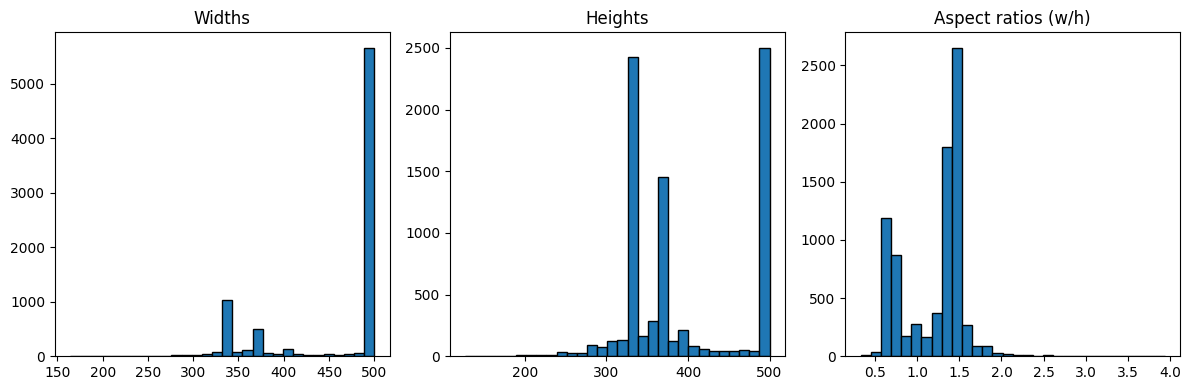

In [17]:
# Histograms of widths, heights, and aspect ratios
valid_sizes = img_stats_df.dropna(subset=['width','height'])
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(valid_sizes['width'], bins=30, edgecolor='black')
plt.title("Widths")
plt.subplot(1,3,2)
plt.hist(valid_sizes['height'], bins=30, edgecolor='black')
plt.title("Heights")
plt.subplot(1,3,3)
plt.hist(valid_sizes['aspect_ratio'], bins=30, edgecolor='black')
plt.title("Aspect ratios (w/h)")
plt.tight_layout()
plt.savefig(OUT_DIR / "image_size_aspect_histograms.png", dpi=150)
plt.show()


13- Detect grayscale / small images and save summary

In [18]:
# Count how many images are grayscale (mode != 'RGB') and how many are very small.
num_grayscale = int((img_stats_df['mode'] != 'RGB').sum())
num_small = int(((img_stats_df['width'] < 100) | (img_stats_df['height'] < 100)).sum())

image_summary = {
    "total_images_scanned": int(len(img_stats_df)),
    "num_grayscale_images": num_grayscale,
    "num_small_images_below_100px": num_small
}
print("Image-level summary:", image_summary)
with open(OUT_DIR / "image_summary.json", "w", encoding="utf-8") as f:
    json.dump(image_summary, f, indent=2)


Image-level summary: {'total_images_scanned': 8091, 'num_grayscale_images': 0, 'num_small_images_below_100px': 0}


Cell 14 — Create sample image grids (for visual report), saved to PNG

In [19]:
# Save a few sample image grids to illustrate dataset diversity.
# I'll pick random images, plus some from specific aspect ratio buckets.

from math import ceil
import random

def save_image_grid(image_list, out_path, cols=5, thumb_size=(224,224)):
    rows = ceil(len(image_list)/cols)
    grid = Image.new('RGB', (cols*thumb_size[0], rows*thumb_size[1]), color=(255,255,255))
    for i, p in enumerate(image_list):
        try:
            with Image.open(p) as im:
                im_thumb = ImageOps.fit(im.convert("RGB"), thumb_size)
            r = i // cols
            c = i % cols
            grid.paste(im_thumb, (c*thumb_size[0], r*thumb_size[1]))
        except Exception as e:
            print("Could not process", p, e)
    grid.save(out_path)

# Random sample
random.seed(0)
sample_paths = random.sample(image_paths, k=20)
save_image_grid(sample_paths, OUT_DIR / "sample_random_grid.png", cols=5)

# Wide aspect examples (w/h > 1.6)
wide = [IMAGE_DIR / r for r in img_stats_df[img_stats_df['aspect_ratio'] > 1.6]['image'].tolist()][:20]
if wide:
    save_image_grid(wide, OUT_DIR / "sample_wide_grid.png", cols=5)

# Tall examples (w/h < 0.6)
tall = [IMAGE_DIR / r for r in img_stats_df[img_stats_df['aspect_ratio'] < 0.6]['image'].tolist()][:20]
if tall:
    save_image_grid(tall, OUT_DIR / "sample_tall_grid.png", cols=5)

print("Saved sample grids. Files in:", OUT_DIR)


Saved sample grids. Files in: /content/eda_outputs


15- Duplicate / near-duplicate detection using perceptual hash (pHash)

In [20]:
# Use imagehash to compute pHash for each image and find duplicates / near-duplicates.
# Near-duplicates can be flagged if hamming distance <= threshold (e.g., 5).

hashes = {}
phash_results = []
for p in tqdm(image_paths, desc="Computing pHash"):
    try:
        with Image.open(p) as im:
            h = imagehash.phash(im.convert("RGB"))
        hashes[p.name] = h
        phash_results.append({"image": p.name, "phash": str(h)})
    except Exception as e:
        phash_results.append({"image": p.name, "phash": None, "error": str(e)})

phash_df = pd.DataFrame(phash_results)
phash_df.to_csv(OUT_DIR / "image_phash.csv", index=False)

# Build near-duplicate groups (simple O(N^2) but ok for ~8k images)
pairs = []
names = list(hashes.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a = names[i]; b = names[j]
        d = (hashes[a] - hashes[b])
        if d <= 5:  # adjust threshold if needed
            pairs.append({"img_a": a, "img_b": b, "hamming": int(d)})

dups_df = pd.DataFrame(pairs)
dups_df.to_csv(OUT_DIR / "near_duplicate_pairs.csv", index=False)
print("Near-duplicate pairs found:", len(dups_df))


Computing pHash: 100%|██████████| 8091/8091 [00:34<00:00, 236.46it/s]


Near-duplicate pairs found: 1


16-Compute global image embeddings with ResNet-50 and do PCA for visualization

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]
Extracting features (this may take a while): 100%|██████████| 8091/8091 [01:35<00:00, 84.75it/s]


Saved embeddings shape: (8091, 2048)


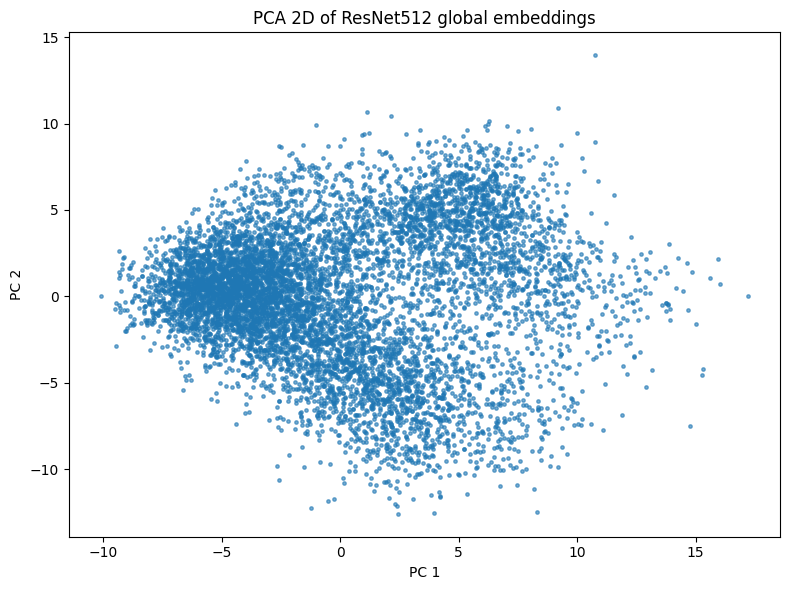

In [21]:
# This cell extracts a 2048-d global embedding per image using ResNet-50 (pretrained).
# It saves embeddings to a .npy file and creates a 2D PCA scatter plot for visual clustering.
# This step can be time-consuming but is useful to see semantic clusters. Although I have a very limited time;
# But, this can give me the perfect understanding of the dataset so that I can decide better for the model architecture.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load a ResNet-50 and chop off the final classifier (I will use the avgpool output)
resnet = models.resnet50(pretrained=True)
resnet.eval()
resnet.to(device)
# Remove final fc: use everything up to avgpool
feature_extractor = torch.nn.Sequential(*(list(resnet.children())[:-1])).to(device)

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

embeddings = []
image_names = []
batch = []
paths_for_batch = []
for p in tqdm(image_paths, desc="Extracting features (this may take a while)"):
    try:
        im = Image.open(p).convert("RGB")
        tensor = transform(im).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = feature_extractor(tensor)  # shape (1, 2048, 1, 1)
            feat = feat.view(feat.size(0), -1).cpu().numpy()  # (1,2048)
        embeddings.append(feat.squeeze(0))
        image_names.append(p.name)
    except Exception as e:
        print("Error extracting for", p, e)

embeddings = np.stack(embeddings, axis=0)  # shape (N, 2048)
np.save(OUT_DIR / "resnet50_global_embeddings.npy", embeddings)
print("Saved embeddings shape:", embeddings.shape)

# PCA to 2D for visualization
pca = PCA(n_components=2)
emb2 = pca.fit_transform(embeddings)
plt.figure(figsize=(8,6))
plt.scatter(emb2[:,0], emb2[:,1], s=6, alpha=0.6)
plt.title("PCA 2D of ResNet512 global embeddings")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.savefig(OUT_DIR / "resnet_embeddings_pca2d.png", dpi=150)
plt.show()

# Save a CSV linking image -> PC coords for later plotting
pd.DataFrame({"image": image_names, "pc1": emb2[:,0].tolist(), "pc2": emb2[:,1].tolist()}).to_csv(OUT_DIR / "image_pca_coords.csv", index=False)


17- Sample qualitative report: show generated CSV/JSON list of interesting caption examples

In [22]:
# Save a few textual examples (longest, shortest, random) to CSV for your report.
longest = caps_df.sort_values("token_len", ascending=False).head(20)[["image","caption","token_len"]]
shortest = caps_df.sort_values("token_len", ascending=True).head(20)[["image","caption","token_len"]]
random_sample = caps_df.sample(40)[["image","caption","token_len"]]

longest.to_csv(OUT_DIR / "captions_longest_examples.csv", index=False)
shortest.to_csv(OUT_DIR / "captions_shortest_examples.csv", index=False)
random_sample.to_csv(OUT_DIR / "captions_random_sample.csv", index=False)
print("Saved example CSVs: longest / shortest / random samples.")


Saved example CSVs: longest / shortest / random samples.


18- Bundle a short JSON report tying together the main numbers

In [23]:
# Compose a short human-friendly report (numbers + paths to saved files)
final_report = {
    "caption_stats": {
        "total_captions": int(total_captions),
        "unique_images": int(unique_images),
        "length_min": int(length_min),
        "length_max": int(length_max),
        "length_mean": float(length_mean),
        "length_median": float(length_median),
        "vocab_size": int(vocab_size)
    },
    "special_tokens_summary": special_summary,
    "image_summary": image_summary,
    "notes": "All outputs (CSVs, PNGs, embeddings, reports) are saved under /content/eda_outputs/. Download them from the Colab Files pane."
}
with open(OUT_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2, ensure_ascii=False)

print("EDA summary saved to:", OUT_DIR / "eda_summary.json")
print("All outputs in folder:", OUT_DIR)


EDA summary saved to: /content/eda_outputs/eda_summary.json
All outputs in folder: /content/eda_outputs


19- Quick listing of saved outputs

In [24]:
# Print the files created so they can be download easily via Colab UI.
print("Files produced (sample listing):")
for p in sorted(OUT_DIR.iterdir()):
    print(" ", p.name, "-", p.stat().st_size, "bytes")

print("\nTo download: from /content/eda_outputs/.")
print("If prefer a single zip, I designed the next cell to create eda_outputs.zip.")


Files produced (sample listing):
  caption_length_distribution.csv - 236 bytes
  caption_length_histogram.png - 31041 bytes
  captions_by_image.json - 3393372 bytes
  captions_longest_examples.csv - 3859 bytes
  captions_random_sample.csv - 3507 bytes
  captions_raw_rows.csv - 3410788 bytes
  captions_shortest_examples.csv - 920 bytes
  captions_special_summary.json - 189 bytes
  captions_text_report.json - 2124 bytes
  eda_summary.json - 717 bytes
  image_pca_coords.csv - 515774 bytes
  image_phash.csv - 346168 bytes
  image_size_aspect_histograms.png - 44723 bytes
  image_stats.csv - 408195 bytes
  image_summary.json - 100 bytes
  near_duplicate_pairs.csv - 74 bytes
  resnet50_global_embeddings.npy - 66281600 bytes
  resnet_embeddings_pca2d.png - 370683 bytes
  sample_random_grid.png - 2017645 bytes
  sample_tall_grid.png - 1971559 bytes
  sample_wide_grid.png - 2005553 bytes
  token_frequency.csv - 2055 bytes
  top_tokens_bar.png - 86247 bytes

To download: from /content/eda_outputs

20- Create a zip of outputs

In [25]:
# To make sure nothing forgot.
# The zip will be in /content .
shutil.make_archive("/content/eda_outputs", "zip", OUT_DIR)
print("Created /content/eda_outputs.zip (downloadable). Size:", Path("/content/eda_outputs.zip").stat().st_size, "bytes")


Created /content/eda_outputs.zip (downloadable). Size: 68497763 bytes
